<style>
.rendered_html h1 { color: #1f4e79; }
.rendered_html h2 { color: #0f766e; }
.rendered_html h3, .rendered_html h4 { color: #7c3aed; }
</style>

# Training Baseline Implicit Matrix Factorization with SGD

This notebook trains a baseline implicit recommendation model using SGD only.

## Setup

We load libraries, set paths, and prepare folders for saved outputs.

In [1]:
from pathlib import Path
import pickle
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

processed_dir = project_root / "data" / "processed"
models_dir = project_root / "models"
figures_dir = project_root / "results" / "figures"
tables_dir = project_root / "results" / "tables"

models_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

## Load Processed Data

Notebook 01 already prepared the train/test split, movies table, and metadata. We load those files directly here.

In [2]:
train_data = pd.read_csv(processed_dir / "train_data.csv")
test_data = pd.read_csv(processed_dir / "test_data.csv")
movies = pd.read_csv(processed_dir / "movies_processed.csv")

with open(processed_dir / "metadata.pkl", "rb") as file:
    metadata = pickle.load(file)

num_users = metadata["num_users"]
num_movies = metadata["num_movies"]

print("Train data:", train_data.shape)
print("Test data:", test_data.shape)
print("Movies:", movies.shape)
print("Users:", num_users)
print("Movies:", num_movies)

Train data: (54433, 7)
Test data: (942, 7)
Movies: (1682, 25)
Users: 943
Movies: 1682


## Reproducibility

We set random seeds so the negative samples and model initialization are easier to reproduce.

In [3]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

## GPU Support

A GPU speeds up tensor operations, especially embedding lookups and batch training. If CUDA is not available, this notebook automatically uses the CPU.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## Negative Sampling

Implicit data only contains positive interactions. `BCEWithLogitsLoss` needs labels `1` and `0`, so we sample unseen movies as negative examples. This helps the model distinguish liked movies from unseen movies.

In [5]:
all_movie_indices = set(range(num_movies))

all_positive_data = pd.concat([train_data, test_data], ignore_index=True)
user_positive_movies = all_positive_data.groupby("user_idx")["movie_idx"].apply(set).to_dict()

rng = np.random.default_rng(seed)
negative_rows = []

for row in train_data.itertuples(index=False):
    seen_movies = user_positive_movies[row.user_idx]
    candidate_movies = list(all_movie_indices - seen_movies)
    negative_movie_idx = int(rng.choice(candidate_movies))
    negative_movie_id = metadata["idx_to_movie"][negative_movie_idx]

    negative_rows.append({
        "user_id": row.user_id,
        "movie_id": negative_movie_id,
        "interaction": 0,
        "timestamp": row.timestamp,
        "user_idx": row.user_idx,
        "movie_idx": negative_movie_idx
    })

negative_samples = pd.DataFrame(negative_rows)
positive_samples = train_data[["user_id", "movie_id", "interaction", "timestamp", "user_idx", "movie_idx"]].copy()

train_with_negatives = pd.concat(
    [positive_samples, negative_samples],
    ignore_index=True
).sample(frac=1, random_state=seed).reset_index(drop=True)

print("Positive samples:", len(positive_samples))
print("Negative samples:", len(negative_samples))
print("Total samples:", len(train_with_negatives))
display(train_with_negatives["interaction"].value_counts().sort_index())

Positive samples: 54433
Negative samples: 54433
Total samples: 108866


interaction
0    54433
1    54433
Name: count, dtype: int64

## PyTorch DataLoader

We convert columns into tensors and create shuffled mini-batches. The default batch size is 512 for a 4GB RTX 3050.

In [6]:
batch_size = 512

user_tensor = torch.tensor(train_with_negatives["user_idx"].values, dtype=torch.long)
movie_tensor = torch.tensor(train_with_negatives["movie_idx"].values, dtype=torch.long)
label_tensor = torch.tensor(train_with_negatives["interaction"].values, dtype=torch.float32)

train_dataset = TensorDataset(user_tensor, movie_tensor, label_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print("Training samples:", len(train_dataset))
print("Batches per epoch:", len(train_loader))

Training samples: 108866
Batches per epoch: 213


## Model

The model learns one embedding vector per user and one embedding vector per movie. Bias terms help capture users or movies that are generally more active or popular.

In [7]:
class ImplicitMatrixFactorization(nn.Module):
    def __init__(self, num_users, num_movies, embedding_dim=32, use_bias=True):
        super().__init__()
        self.user_embeddings = nn.Embedding(num_users, embedding_dim)
        self.movie_embeddings = nn.Embedding(num_movies, embedding_dim)
        self.use_bias = use_bias

        if use_bias:
            self.user_bias = nn.Embedding(num_users, 1)
            self.movie_bias = nn.Embedding(num_movies, 1)

        nn.init.normal_(self.user_embeddings.weight, mean=0.0, std=0.01)
        nn.init.normal_(self.movie_embeddings.weight, mean=0.0, std=0.01)

        if use_bias:
            nn.init.zeros_(self.user_bias.weight)
            nn.init.zeros_(self.movie_bias.weight)

    def forward(self, user_idx, movie_idx):
        user_vector = self.user_embeddings(user_idx)
        movie_vector = self.movie_embeddings(movie_idx)
        score = (user_vector * movie_vector).sum(dim=1)

        if self.use_bias:
            score = score + self.user_bias(user_idx).squeeze(1)
            score = score + self.movie_bias(movie_idx).squeeze(1)

        return score


embedding_dim = 32
model = ImplicitMatrixFactorization(num_users, num_movies, embedding_dim=embedding_dim).to(device)
model

ImplicitMatrixFactorization(
  (user_embeddings): Embedding(943, 32)
  (movie_embeddings): Embedding(1682, 32)
  (user_bias): Embedding(943, 1)
  (movie_bias): Embedding(1682, 1)
)

## Train with SGD

We use binary cross-entropy with logits and plain SGD. We track average loss, elapsed time, and GPU memory when available.

In [8]:
loss_function = nn.BCEWithLogitsLoss()
learning_rate = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

num_epochs = 30
history = []

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

training_start = time.time()

for epoch in range(1, num_epochs + 1):
    model.train()
    epoch_start = time.time()
    total_loss = 0.0
    total_examples = 0

    for batch_users, batch_movies, batch_labels in train_loader:
        batch_users = batch_users.to(device)
        batch_movies = batch_movies.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        scores = model(batch_users, batch_movies)
        loss = loss_function(scores, batch_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(batch_labels)
        total_examples += len(batch_labels)

    average_loss = total_loss / total_examples
    epoch_time = time.time() - epoch_start
    elapsed_time = time.time() - training_start

    if device.type == "cuda":
        memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    else:
        memory_mb = None

    history.append({
        "epoch": epoch,
        "loss": average_loss,
        "epoch_time_sec": epoch_time,
        "elapsed_time_sec": elapsed_time,
        "gpu_memory_mb": memory_mb
    })

    print(f"Epoch {epoch:02d}/{num_epochs} - Loss: {average_loss:.4f} - Time: {epoch_time:.2f}s")

training_time = time.time() - training_start
print(f"Total training time: {training_time:.2f}s")

Epoch 01/30 - Loss: 0.6925 - Time: 2.19s
Epoch 02/30 - Loss: 0.6913 - Time: 2.41s
Epoch 03/30 - Loss: 0.6900 - Time: 1.94s
Epoch 04/30 - Loss: 0.6888 - Time: 2.05s
Epoch 05/30 - Loss: 0.6875 - Time: 2.39s
Epoch 06/30 - Loss: 0.6863 - Time: 1.83s
Epoch 07/30 - Loss: 0.6851 - Time: 2.25s
Epoch 08/30 - Loss: 0.6839 - Time: 2.44s
Epoch 09/30 - Loss: 0.6827 - Time: 2.01s
Epoch 10/30 - Loss: 0.6815 - Time: 2.37s
Epoch 11/30 - Loss: 0.6804 - Time: 2.20s
Epoch 12/30 - Loss: 0.6792 - Time: 1.74s
Epoch 13/30 - Loss: 0.6781 - Time: 1.75s
Epoch 14/30 - Loss: 0.6769 - Time: 1.74s
Epoch 15/30 - Loss: 0.6758 - Time: 3.25s
Epoch 16/30 - Loss: 0.6747 - Time: 4.08s
Epoch 17/30 - Loss: 0.6736 - Time: 4.47s
Epoch 18/30 - Loss: 0.6725 - Time: 4.07s
Epoch 19/30 - Loss: 0.6714 - Time: 4.30s
Epoch 20/30 - Loss: 0.6704 - Time: 4.50s
Epoch 21/30 - Loss: 0.6693 - Time: 4.19s
Epoch 22/30 - Loss: 0.6683 - Time: 4.40s
Epoch 23/30 - Loss: 0.6672 - Time: 4.14s
Epoch 24/30 - Loss: 0.6662 - Time: 4.43s
Epoch 25/30 - Lo

## Loss Curve

The loss curve helps us see whether SGD is converging over epochs.

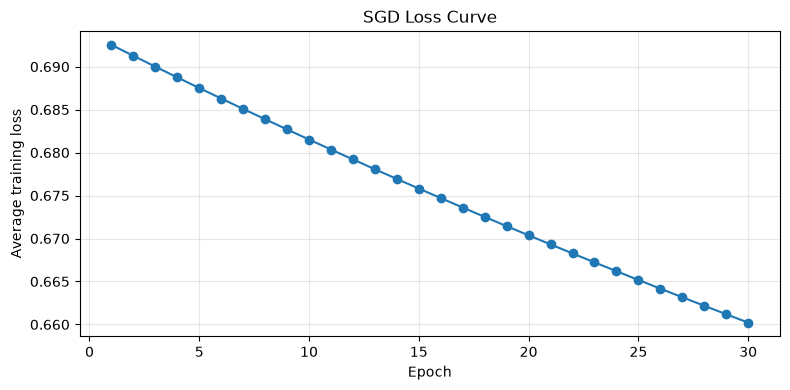

In [9]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average training loss")
plt.title("SGD Loss Curve")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "sgd_loss_curve.png", dpi=150)
plt.show()

## Save Outputs

We save the trained weights and training history for evaluation and later comparison.

In [10]:
model_path = models_dir / "mf_sgd.pth"
history_path = tables_dir / "sgd_training_history.csv"

torch.save({
    "model_state_dict": model.state_dict(),
    "num_users": num_users,
    "num_movies": num_movies,
    "embedding_dim": embedding_dim,
    "learning_rate": learning_rate,
    "num_epochs": num_epochs,
    "training_time_sec": training_time
}, model_path)

history_df.to_csv(history_path, index=False)

print("Saved model to:", model_path)
print("Saved training history to:", history_path)
print("Saved loss curve to:", figures_dir / "sgd_loss_curve.png")

Saved model to: c:\Users\abdoi\OneDrive\Documents\Studies\master ai\S2\Optimisation\projet\workspace\models\mf_sgd.pth
Saved training history to: c:\Users\abdoi\OneDrive\Documents\Studies\master ai\S2\Optimisation\projet\workspace\results\tables\sgd_training_history.csv
Saved loss curve to: c:\Users\abdoi\OneDrive\Documents\Studies\master ai\S2\Optimisation\projet\workspace\results\figures\sgd_loss_curve.png


## Conclusion

The baseline model learned user and movie embeddings using SGD. The loss curve shows how the training objective converged over epochs.

This saved model will be evaluated in notebook 03.